# EDA

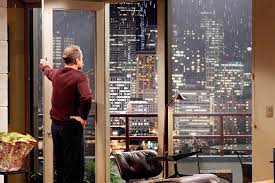

## Client profile
Thomas Hansen(Buyer)
5 kids, no money, wants nice (social) neighborhood, Timing?, Location?


## Hypothesis

1. Do homes with more bedrooms relative to sqft_living cost less per bedroom in certain zipcodes?
2. Does price dip in certain months (date), suggesting a better time to buy on a tight budget?
3. Does having basement on the hause siginficatly affect the price.

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

## Importing dataset

In [3]:
# importing data
df_house = pd.read_csv("data/_SELECT_FROM_king_county_house_sales_kchs_INNER_JOIN_king_county_202609151321.csv", sep = ",")

In [4]:
#printing dataset and make sure it is loaded on the coding environment
df_house

,date,price,house_id,id,id.1,bedrooms,bathrooms,sqft_living,sqft_lot,floors,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900.000,7129300520,1,7129300520,3.000,1.000,1180.000,5650.000,1.000,...,7,1180.000,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000
1,2014-12-09,538000.000,6414100192,2,6414100192,3.000,2.250,2570.000,7242.000,2.000,...,7,2170.000,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000
2,2015-02-25,180000.000,5631500400,3,5631500400,2.000,1.000,770.000,10000.000,1.000,...,6,770.000,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000
3,2014-12-09,604000.000,2487200875,4,2487200875,4.000,3.000,1960.000,5000.000,1.000,...,7,1050.000,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000
4,2015-02-18,510000.000,1954400510,5,1954400510,3.000,2.000,1680.000,8080.000,1.000,...,8,1680.000,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,2014-05-21,360000.000,263000018,21593,263000018,3.000,2.500,1530.000,1131.000,3.000,...,8,1530.000,0.000,2009,0.000,98103,47.699,-122.346,1530.000,1509.000
21593,2015-02-23,400000.000,6600060120,21594,6600060120,4.000,2.500,2310.000,5813.000,2.000,...,8,2310.000,0.000,2014,0.000,98146,47.511,-122.362,1830.000,7200.000
21594,2014-06-23,402101.000,1523300141,21595,1523300141,2.000,0.750,1020.000,1350.000,2.000,...,7,1020.000,0.000,2009,0.000,98144,47.594,-122.299,1020.000,2007.000
21595,2015-01-16,400000.000,291310100,21596,291310100,3.000,2.500,1600.000,2388.000,2.000,...,8,1600.000,0.000,2004,0.000,98027,47.535,-122.069,1410.000,1287.000


## Data cleaning

In [5]:
# checking the shape of the dataset
df_house.shape

(21597, 23)

In [6]:
# basic information about the dataset
df_house.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           21597 non-null  str    
 1   price          21597 non-null  float64
 2   house_id       21597 non-null  int64  
 3   id             21597 non-null  int64  
 4   id.1           21597 non-null  int64  
 5   bedrooms       21597 non-null  float64
 6   bathrooms      21597 non-null  float64
 7   sqft_living    21597 non-null  float64
 8   sqft_lot       21597 non-null  float64
 9   floors         21597 non-null  float64
 10  waterfront     19206 non-null  float64
 11  view           21534 non-null  float64
 12  condition      21597 non-null  int64  
 13  grade          21597 non-null  int64  
 14  sqft_above     21597 non-null  float64
 15  sqft_basement  21145 non-null  float64
 16  yr_built       21597 non-null  int64  
 17  yr_renovated   17749 non-null  float64
 18  zipcode        21

In [7]:
# removing unnecessary columns
df_house = df_house.drop(columns = ["house_id", "id", "id.1"])     
df_house.columns                

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='str')

In [8]:
# fixing type of data

df_house["date"] = pd.to_datetime(df_house["date"], format = "%Y-%m-%d")
df_house["yr_built"] = pd.to_datetime(df_house["yr_built"], format = "%Y")
df_house.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           21597 non-null  datetime64[us]
 1   price          21597 non-null  float64       
 2   bedrooms       21597 non-null  float64       
 3   bathrooms      21597 non-null  float64       
 4   sqft_living    21597 non-null  float64       
 5   sqft_lot       21597 non-null  float64       
 6   floors         21597 non-null  float64       
 7   waterfront     19206 non-null  float64       
 8   view           21534 non-null  float64       
 9   condition      21597 non-null  int64         
 10  grade          21597 non-null  int64         
 11  sqft_above     21597 non-null  float64       
 12  sqft_basement  21145 non-null  float64       
 13  yr_built       21597 non-null  datetime64[us]
 14  yr_renovated   17749 non-null  float64       
 15  zipcode        21597 non-null 

In [9]:
# dealing with duplicated rows
df_house.duplicated().value_counts()

False    21597
Name: count, dtype: int64

In [10]:
# basic discription of continous columans in the dataset
df_house.describe()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21597,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,19206.000,21534.000,21597.000,21597.000,21597.000,21145.000,21597,17749.000,21597.000,21597.000,21597.000,21597.000,21597.000
mean,2014-10-29 04:20:38.171968,540296.574,3.373,2.116,2080.322,15099.409,1.494,0.008,0.234,3.410,7.658,1788.597,291.857,1971-01-01 00:15:16.127239,836.651,98077.952,47.560,-122.214,1986.620,12758.284
min,2014-05-02 00:00:00,78000.000,1.000,0.500,370.000,520.000,1.000,0.000,0.000,1.000,3.000,370.000,0.000,1900-01-01 00:00:00,0.000,98001.000,47.156,-122.519,399.000,651.000
25%,2014-07-22 00:00:00,322000.000,3.000,1.750,1430.000,5040.000,1.000,0.000,0.000,3.000,7.000,1190.000,0.000,1951-01-01 00:00:00,0.000,98033.000,47.471,-122.328,1490.000,5100.000
50%,2014-10-16 00:00:00,450000.000,3.000,2.250,1910.000,7618.000,1.500,0.000,0.000,3.000,7.000,1560.000,0.000,1975-01-01 00:00:00,0.000,98065.000,47.572,-122.231,1840.000,7620.000
75%,2015-02-17 00:00:00,645000.000,4.000,2.500,2550.000,10685.000,2.000,0.000,0.000,4.000,8.000,2210.000,560.000,1997-01-01 00:00:00,0.000,98118.000,47.678,-122.125,2360.000,10083.000
max,2015-05-27 00:00:00,7700000.000,33.000,8.000,13540.000,1651359.000,3.500,1.000,4.000,5.000,13.000,9410.000,4820.000,2015-01-01 00:00:00,20150.000,98199.000,47.778,-121.315,6210.000,871200.000
std,NaN,367368.140,0.926,0.769,918.106,41412.637,0.540,0.087,0.766,0.651,1.173,827.760,442.491,NaN,4000.111,53.513,0.139,0.141,685.230,27274.442


In [11]:
#evaluate and correcting unusual values from description
df_house[df_house["bathrooms"] < 1]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
208,2014-11-23,180250.000,2.000,0.750,900.000,9600.000,1.000,0.000,0.000,3,6,900.000,0.000,1941-01-01,0.000,98166,47.460,-122.339,1250.000,14280.000
264,2014-10-27,369900.000,1.000,0.750,760.000,10079.000,1.000,1.000,4.000,5,5,760.000,0.000,1936-01-01,0.000,98070,47.468,-122.438,1230.000,14267.000
350,2014-06-04,299000.000,1.000,0.750,560.000,12120.000,1.000,NaN,0.000,3,4,560.000,0.000,1967-01-01,0.000,98014,47.675,-121.854,1300.000,19207.000
465,2014-05-23,80000.000,1.000,0.750,430.000,5050.000,1.000,NaN,0.000,2,4,430.000,0.000,1912-01-01,0.000,98014,47.650,-121.909,1200.000,7500.000
569,2014-12-18,405000.000,2.000,0.750,1160.000,15029.000,1.000,0.000,0.000,4,6,870.000,290.000,1937-01-01,0.000,98014,47.693,-121.870,1870.000,25346.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19183,2015-01-22,699999.000,3.000,0.750,1240.000,4000.000,1.000,0.000,0.000,4,7,1240.000,0.000,1968-01-01,0.000,98112,47.624,-122.297,1460.000,4000.000
19329,2015-03-01,151000.000,2.000,0.750,720.000,5040.000,1.000,0.000,0.000,3,4,720.000,0.000,1949-01-01,NaN,98106,47.532,-122.347,1290.000,4120.000
20001,2014-09-23,290000.000,1.000,0.750,740.000,1284.000,1.000,0.000,0.000,4,6,740.000,0.000,1928-01-01,0.000,98107,47.674,-122.406,1430.000,3988.000
21594,2014-06-23,402101.000,2.000,0.750,1020.000,1350.000,2.000,0.000,0.000,3,7,1020.000,0.000,2009-01-01,0.000,98144,47.594,-122.299,1020.000,2007.000


In [12]:
#adjusting values for bathroom column
df_house.loc[df_house["bathrooms"] < 1, "bathrooms"] = 1
df_house["bathrooms"].describe()

count   21597.000
mean        2.117
std         0.767
min         1.000
25%         1.750
50%         2.250
75%         2.500
max         8.000
Name: bathrooms, dtype: float64

In [13]:
# dealing with missing variables
df_house.isna().sum()

date                0
price               0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
dtype: int64

In [26]:
# Do imputation for variables relevant to hypothesis testing
# dealing missing value for sqft_basement

df_house["sqft_basement"] = df_house["sqft_basement"].fillna(0)
df_house["waterfront"] = df_house["waterfront"].fillna(0)
df_house["view"] = df_house["view"].fillna(0)


In [27]:
#checking if imputation works

df_house.isna().sum()

date                0
price               0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront          0
view                0
condition           0
grade               0
sqft_above          0
sqft_basement       0
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
dtype: int64

In [ ]:
# note: yr_renovated will be removed from the analysis because it has a lot of missing values

## EDA first hypothesis

In [28]:
# creating a datafile that meets my client need, more bedroom, having basement
df_house
#creating a new variable price price/sq foot

df_house["price_sq_foot"] = df_house["price"] / (df_house["sqft_living"] + df_house["sqft_lot"] + df_house["sqft_above"] + df_house["sqft_basement"])

In [29]:
df_house["price_sq_foot"].describe()

count   21597.000
mean       46.576
std        31.081
min         0.163
25%        24.201
50%        38.730
75%        61.663
max       249.035
Name: price_sq_foot, dtype: float64

In [30]:
# classifiying Zip codes as urban, semi urban, and rural based on geogrpahical knowledge only

URBAN = [

    98102, 98103, 98105, 98106, 98107, 98108, 98109, 98112, 98115, 98116,
    98117, 98118, 98119, 98122, 98125, 98126, 98133, 98136, 98144, 98177,
    98178, 98199, 98004, 98033,
]

SUBURBAN = [
    
    98005, 98006, 98007, 98008, 98011, 98023, 98027, 98028, 98029, 98030,
    98031, 98032, 98034, 98052, 98055, 98056, 98058, 98059, 98074, 98075,
    98092, 98146, 98148, 98155, 98166, 98168, 98188, 98198,
    98039, 98040, 98053, 98072, 98077,
]

RURAL = [
  
    98001, 98002, 98003, 98010, 98019, 98024, 98038, 98042, 98065,
    98014, 98022, 98045, 98070,
]

In [31]:
# creating new variable to put this geogrpahical classifications
 
df_house["urban_classification"] = "Unclassified"

df_house.loc[df_house["zipcode"].isin(URBAN), "urban_classification"] = "Urban"
df_house.loc[df_house["zipcode"].isin(SUBURBAN), "urban_classification"] = "Suburban"
df_house.loc[df_house["zipcode"].isin(RURAL), "urban_classification"] = "Rural"

In [32]:
# checking weather its categorized correctly
df_house["urban_classification"].unique()

<StringArray>
['Urban', 'Suburban', 'Rural']
Length: 3, dtype: str

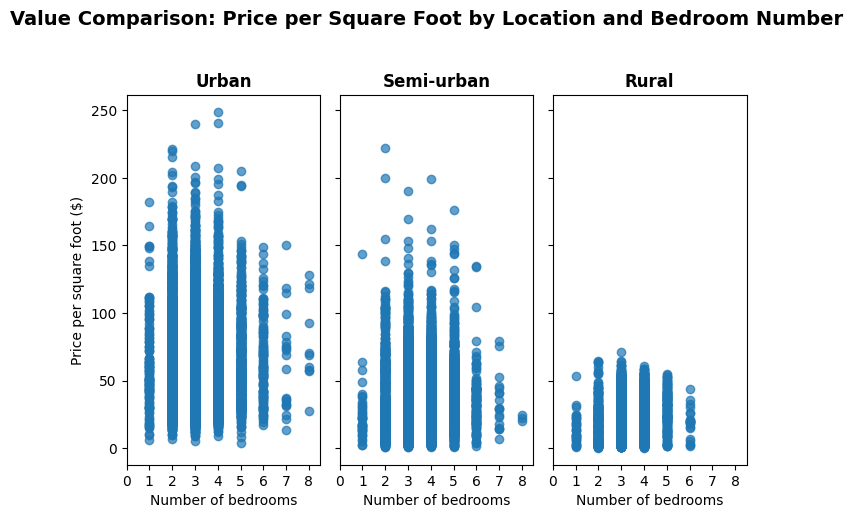

In [36]:
# creating a graph for hypothesis one

# Rename the classification values for presentation
df_house['urban_classification'] = df_house['urban_classification'].replace(
    {'Suburban': 'Semi-urban'}
)

# Order and titles
facet_order = ['Urban', 'Semi-urban', 'Rural']
facet_titles = ['Urban', 'Semi-urban', 'Rural']  

fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(8, 5),
    sharey=True,
)

for ax, category, title in zip(axes, facet_order, facet_titles):
    subset = df_house[df_house['urban_classification'] == category]
    ax.scatter(subset['bedrooms'], subset['price_sq_foot'], alpha=0.7)

    ax.set_title(title, fontsize=12, fontweight="bold")  
    ax.set_xlim(0, 8.5)
    ax.set_xticks(range(0, 9))
    ax.set_xlabel("Number of bedrooms")

axes[0].set_ylabel("Price per square foot ($)")

fig.suptitle(
    "Value Comparison: Price per Square Foot by Location and Bedroom Number",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

fig.subplots_adjust(wspace=0.1, top=0.85)
plt.show()

## EDA testing the second hypothesis

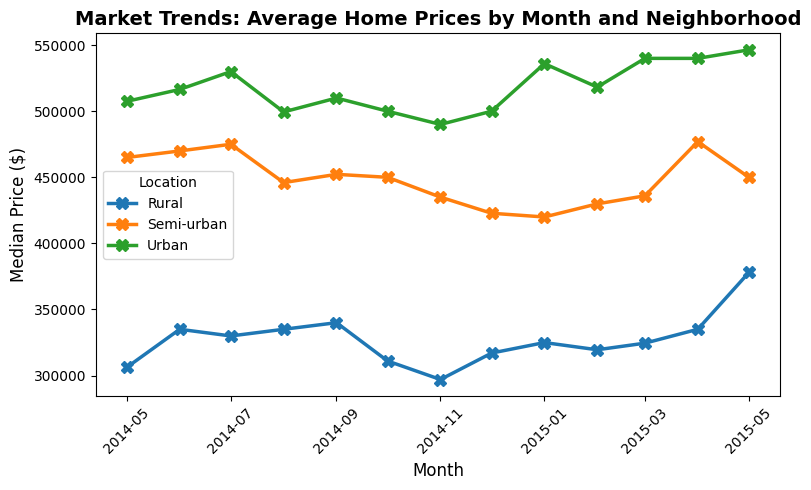

In [41]:
# Creating graph showing trend of median price by date, without classifying the date to month

fig, ax = plt.subplots(figsize=(8, 5))

df_house["year_month"] = df_house["date"].dt.to_period("M").dt.to_timestamp()

monthly_median = (
    df_house.groupby(["year_month", "urban_classification"])["price"]
    .median()
    .reset_index()
)

for classification, group in monthly_median.groupby("urban_classification"):
    ax.plot(
        group["year_month"],
        group["price"],
        linewidth=2.5,
        marker="X",
        markersize=8,
        label=classification,
    )

ax.set_title("Market Trends: Average Home Prices by Month and Neighborhood", fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Median Price ($)", fontsize=12)
ax.legend(title="Location")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# checking the start date of the dataset
df_house["date"].sort_values().head()

7316    2014-05-02
20586   2014-05-02
1040    2014-05-02
20543   2014-05-02
9587    2014-05-02
Name: date, dtype: datetime64[us]

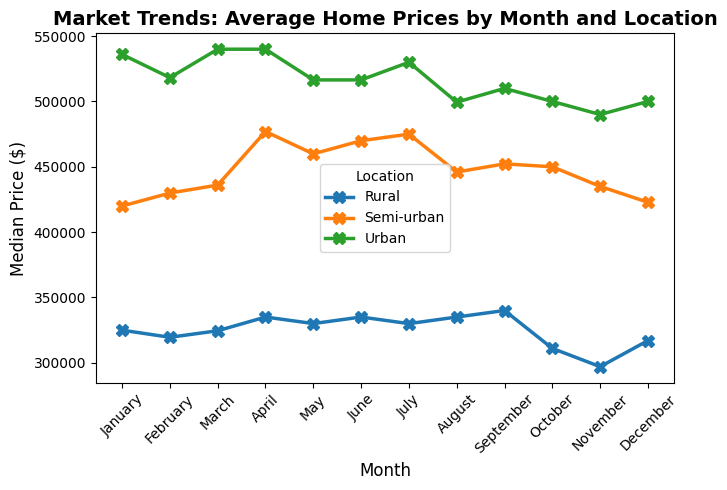

In [42]:
#creating graph to show the trend of price per month 

fig, ax = plt.subplots(figsize=(7, 5))

df_house["month"] = df_house["date"].dt.month_name()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]

monthly_median = (
    df_house.groupby(["month", "urban_classification"])["price"]
    .median()
    .reset_index()
)

monthly_median["month"] = pd.Categorical(
    monthly_median["month"], categories=month_order, ordered=True
)

monthly_median = monthly_median.sort_values("month")


for classification, group in monthly_median.groupby("urban_classification"):
    ax.plot(
        group["month"],
        group["price"],
        linewidth=2.5,
        marker="X",
        markersize=8,
        label=classification,
    )

ax.set_title("Market Trends: Average Home Prices by Month and Location", fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Median Price ($)", fontsize=12)
ax.legend(title="Location")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## ## EDA testing the the third hypothesis

In [43]:
#creating categorical variable for avaliablity of basement

df_house["basement"] = pd.cut(df_house["sqft_basement"], 
                              bins = [-1, 0, float("inf")],
                              labels = ["No Basement", "Has Basement"])

In [44]:
#checking if its properly categorized

df_house[["sqft_basement", "basement"]]

,sqft_basement,basement
0,0.000,No Basement
1,400.000,Has Basement
2,0.000,No Basement
3,910.000,Has Basement
4,0.000,No Basement
...,...,...
21592,0.000,No Basement
21593,0.000,No Basement
21594,0.000,No Basement
21595,0.000,No Basement


In [45]:
# Calculating the median price based on availability of basement

median_price_basement = df_house.groupby(["basement"])["price"].median().reindex(["No Basement", "Has Basement"])

In [47]:
# checking the output
median_price_basement

basement
No Basement    415000.000
Has Basement   515000.000
Name: price, dtype: float64

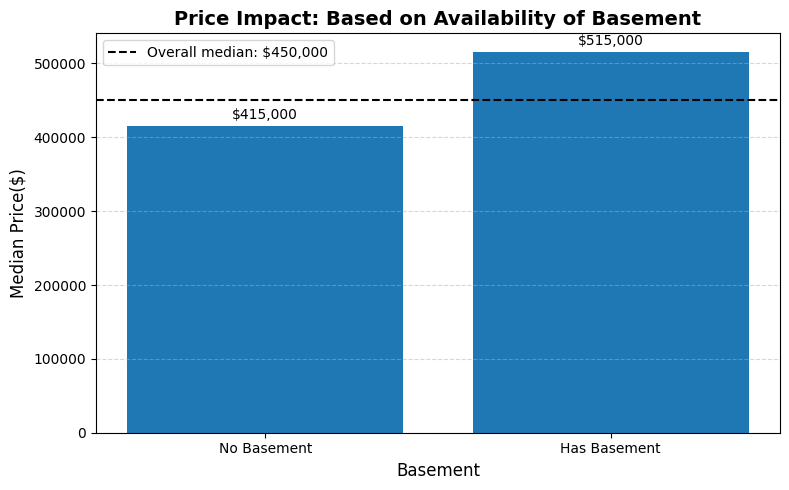

In [ ]:
# creating bargraph 

fig, ax = plt.subplots(figsize=(8, 5))

overall_median = df_house["price"].median()

bars = ax.bar(
    median_price_basement.index,
    median_price_basement.values,
)

ax.set_title("Price Impact: Based on Availability of Basement", fontsize=14, fontweight="bold")
ax.set_xlabel("Basement", fontsize=12)
ax.set_ylabel("Median Price($)", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.bar_label(bars, padding=3, fmt='${:,.0f}')
ax.axhline(
    overall_median,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall median: ${overall_median:,.0f}",
)

ax.legend()
plt.tight_layout()
plt.show()
